# Medical Diagnostic Expert System
**Name:** Rediet Samuel,
**ID:** MTUPR/2032/18,
**Course:** MSIT5205 – Advanced Artificial Intelligence  
**Track:** B – Knowledge Representation  
**Technique:** Rule-Based Backward Chaining

> **Disclaimer:** This system is for educational purposes only. Always consult a qualified physician.

---
### Notebook Structure
| Cell | Content |
|------|---------|
| 1 | Knowledge Base – disease rules & symptom labels |
| 2 | Inference Engine – backward chaining + explanation |
| 3 | Interactive Diagnosis UI (ipywidgets) |
| 4 | Automated Test Suite |
| 5 | Visualisations – symptom heatmap & coverage chart |

## Cell 1 – Knowledge Base

In [9]:
# =============================================================
# KNOWLEDGE BASE
# Disease rules: disease -> list of required symptoms
# Backward chaining proves a disease by confirming ALL symptoms.
# =============================================================

DISEASE_RULES = {
    'Malaria':       ['fever','chills','sweating','headache','nausea','muscle_pain'],
    'Typhoid':       ['fever','abdominal_pain','weakness','loss_of_appetite','headache','constipation_or_diarrhea'],
    'Influenza':     ['fever','cough','sore_throat','runny_nose','muscle_pain','fatigue'],
    'Tuberculosis':  ['persistent_cough','night_sweats','weight_loss','fatigue','chest_pain','coughing_blood'],
    'Pneumonia':     ['fever','cough','chest_pain','shortness_of_breath','fatigue','sweating'],
    'Dengue':        ['fever','severe_headache','pain_behind_eyes','joint_pain','rash','nausea'],
    'COVID-19':      ['fever','cough','shortness_of_breath','loss_of_taste_or_smell','fatigue','sore_throat'],
    'Cholera':       ['watery_diarrhea','nausea','vomiting','muscle_cramps','dehydration'],
    'Meningitis':    ['severe_headache','fever','stiff_neck','sensitivity_to_light','nausea','vomiting'],
    'Hepatitis_B':   ['jaundice','abdominal_pain','dark_urine','fatigue','nausea','joint_pain'],
    'Diabetes':      ['frequent_urination','excessive_thirst','unexplained_weight_loss','fatigue','blurred_vision','slow_healing'],
    'Hypertension':  ['severe_headache','shortness_of_breath','nosebleed','chest_pain','dizziness'],
}

# Human-readable labels shown in prompts and explanations
SYMPTOM_LABELS = {
    'fever':                    'Fever',
    'chills':                   'Chills',
    'sweating':                 'Sweating',
    'headache':                 'Headache',
    'nausea':                   'Nausea',
    'muscle_pain':              'Muscle pain',
    'abdominal_pain':           'Abdominal pain',
    'weakness':                 'Weakness / general malaise',
    'loss_of_appetite':         'Loss of appetite',
    'constipation_or_diarrhea': 'Constipation or diarrhea',
    'cough':                    'Cough',
    'sore_throat':              'Sore throat',
    'runny_nose':               'Runny nose',
    'fatigue':                  'Fatigue',
    'persistent_cough':         'Persistent cough (> 2 weeks)',
    'night_sweats':             'Night sweats',
    'weight_loss':              'Unexplained weight loss',
    'chest_pain':               'Chest pain',
    'coughing_blood':           'Coughing up blood',
    'shortness_of_breath':      'Shortness of breath',
    'severe_headache':          'Severe headache',
    'pain_behind_eyes':         'Pain behind the eyes',
    'joint_pain':               'Joint pain',
    'rash':                     'Skin rash',
    'loss_of_taste_or_smell':   'Loss of taste or smell',
    'watery_diarrhea':          'Profuse watery diarrhea',
    'vomiting':                 'Vomiting',
    'muscle_cramps':            'Muscle cramps',
    'dehydration':              'Signs of dehydration',
    'stiff_neck':               'Stiff neck',
    'sensitivity_to_light':     'Sensitivity to light (photophobia)',
    'jaundice':                 'Yellowing of skin/eyes (jaundice)',
    'dark_urine':               'Dark-coloured urine',
    'frequent_urination':       'Frequent urination',
    'excessive_thirst':         'Excessive thirst',
    'unexplained_weight_loss':  'Unexplained weight loss',
    'blurred_vision':           'Blurred vision',
    'slow_healing':             'Slow-healing wounds/sores',
    'nosebleed':                'Nosebleeds',
    'dizziness':                'Dizziness',
}

print(f'Knowledge base loaded: {len(DISEASE_RULES)} diseases, {len(SYMPTOM_LABELS)} symptoms.')

Knowledge base loaded: 12 diseases, 40 symptoms.


## Cell 2 – Inference Engine

In [12]:
# =============================================================
# INFERENCE ENGINE
# Backward chaining: for each goal disease, prove it by
# checking all required symptoms against the fact base.
# Includes WHY and HOW explanation facilities.
# =============================================================

class InferenceEngine:
    """Backward chaining engine with explanation facility."""

    def __init__(self):
        self.facts       = {}   # symptom -> True/False
        self.proof_trace = {}   # disease -> [(symptom, present), ...]
        self.matched     = []   # fully confirmed diseases
        self.partial     = {}   # disease -> (confirmed_count, total)

    # ── Public API ───────────────────────────────────────────

    def diagnose(self, target_disease=None):
        """Run backward chaining. Returns list of confirmed diseases."""
        self.matched = []
        self.partial = {}
        self.proof_trace = {}
        goals = [target_disease] if target_disease else list(DISEASE_RULES.keys())
        for disease in goals:
            self._prove_goal(disease)
        return self.matched

    def explain_how(self, disease):
        """HOW explanation: proof trace showing each symptom verdict."""
        if disease not in self.proof_trace:
            return f'No proof trace available for {disease}.'
        lines = [f'\n[HOW] Proof trace for "{disease}":']
        for symptom, present in self.proof_trace[disease]:
            label  = SYMPTOM_LABELS.get(symptom, symptom)
            status = '✔ CONFIRMED' if present else '✘ NOT PRESENT'
            lines.append(f'  {status} — {label}')
        all_ok = all(p for _, p in self.proof_trace[disease])
        if all_ok:
            lines.append(f'  ➜ CONCLUSION: All symptoms confirmed → {disease} diagnosed.')
        else:
            lines.append(f'  ➜ CONCLUSION: Not all symptoms confirmed → {disease} ruled out.')
        return '\n'.join(lines)

    def explain_why(self, symptom):
        """WHY explanation: lists every disease that requires this symptom."""
        relevant = [d for d, syms in DISEASE_RULES.items() if symptom in syms]
        label    = SYMPTOM_LABELS.get(symptom, symptom)
        if not relevant:
            return f"Symptom '{label}' is not referenced in any disease rule."
        lines = [f'\n[WHY] You are being asked about: "{label}"',
                 '  This symptom is needed to evaluate:']
        for d in relevant:
            lines.append(f'    • {d}')
        return '\n'.join(lines)

    def reset(self):
        """Clear all facts and traces for a fresh session."""
        self.facts.clear()
        self.proof_trace.clear()
        self.matched.clear()
        self.partial.clear()

    # ── Internal helpers ─────────────────────────────────────

    def _prove_goal(self, disease):
        """Attempt to prove a single disease via backward chaining."""
        required = DISEASE_RULES.get(disease, [])
        trace, count = [], 0
        for symptom in required:
            present = self._check_symptom(symptom)
            trace.append((symptom, present))
            if present:
                count += 1
            else:
                # Continue collecting remaining facts for full trace
                for rem in required[len(trace):]:
                    p = self._check_symptom(rem)
                    trace.append((rem, p))
                    if p:
                        count += 1
                break
        self.proof_trace[disease] = trace
        self.partial[disease]     = (count, len(required))
        if count == len(required):
            self.matched.append(disease)
            return True
        return False

    def _check_symptom(self, symptom):
        """Look up fact; if unknown, return False (notebook uses widget UI)."""
        return self.facts.get(symptom, False)


print('InferenceEngine class defined.')

InferenceEngine class defined.


## Cell 3 – Interactive Diagnosis UI
Run this cell and use the checkboxes to select your symptoms, then click **Run Diagnosis**.

In [11]:
# =============================================================
# INTERACTIVE UI  (requires ipywidgets)
# Install if needed:  pip install ipywidgets
# =============================================================
import ipywidgets as widgets
from IPython.display import display, HTML

engine = InferenceEngine()

# ── Build one checkbox per symptom ───────────────────────────
all_symptoms = sorted(SYMPTOM_LABELS.keys())
checkboxes   = {
    s: widgets.Checkbox(
        value=False,
        description=SYMPTOM_LABELS[s],
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='340px')
    )
    for s in all_symptoms
}

# ── Layout: two columns of checkboxes ────────────────────────
mid   = len(all_symptoms) // 2
col1  = widgets.VBox(list(checkboxes.values())[:mid])
col2  = widgets.VBox(list(checkboxes.values())[mid:])
grid  = widgets.HBox([col1, col2])

# ── Controls ─────────────────────────────────────────────────
disease_dropdown = widgets.Dropdown(
    options=['All diseases'] + list(DISEASE_RULES.keys()),
    description='Target:',
    layout=widgets.Layout(width='280px')
)
run_btn          = widgets.Button(description='Run Diagnosis',   button_style='primary')
reset_btn        = widgets.Button(description='Reset',           button_style='warning')
how_dropdown     = widgets.Dropdown(options=[], description='HOW:', layout=widgets.Layout(width='280px'))
how_btn          = widgets.Button(description='Show HOW Explanation', button_style='info')
output           = widgets.Output()

SEP = '=' * 58

def on_run(_):
    """Collect checkbox facts, run engine, display results."""
    engine.reset()
    # Inject facts from checkboxes
    for symptom, cb in checkboxes.items():
        engine.facts[symptom] = cb.value

    target  = None if disease_dropdown.value == 'All diseases' else disease_dropdown.value
    matched = engine.diagnose(target_disease=target)

    with output:
        output.clear_output()
        print(SEP)
        print('  DIAGNOSIS RESULTS')
        print(SEP)

        selected = [SYMPTOM_LABELS[s] for s, cb in checkboxes.items() if cb.value]
        print(f'\nSymptoms reported ({len(selected)}):')
        for s in selected:
            print(f'  • {s}')

        print()
        if matched:
            print(f'✔ Confirmed diagnosis/diagnoses ({len(matched)}):')
            for d in matched:
                print(f'   ➜ {d}')
        else:
            print('✘ No disease fully confirmed based on reported symptoms.')

        # Partial matches
        partials = [
            (d, cnt, tot)
            for d, (cnt, tot) in engine.partial.items()
            if d not in matched and cnt > 0
        ]
        if partials:
            partials.sort(key=lambda x: x[1]/x[2], reverse=True)
            print('\nClose partial matches (consult a doctor):')
            for d, cnt, tot in partials[:5]:
                pct = int(cnt/tot*100)
                bar = '█' * pct + '░' * (100-pct)
                print(f'  {d:<18} {cnt}/{tot} ({pct:3}%) |{bar[:30]}|')

    # Populate HOW dropdown
    how_dropdown.options = list(engine.proof_trace.keys())

def on_reset(_):
    """Clear all checkboxes and output."""
    for cb in checkboxes.values():
        cb.value = False
    engine.reset()
    how_dropdown.options = []
    with output:
        output.clear_output()
        print('Session reset.')

def on_how(_):
    """Print HOW explanation for selected disease."""
    disease = how_dropdown.value
    if not disease:
        return
    with output:
        print(engine.explain_how(disease))

run_btn.on_click(on_run)
reset_btn.on_click(on_reset)
how_btn.on_click(on_how)

# ── Render ───────────────────────────────────────────────────
display(
    HTML('<h3 style="color:#2c3e50">Select your symptoms:</h3>'),
    grid,
    widgets.HBox([disease_dropdown, run_btn, reset_btn]),
    widgets.HBox([how_dropdown, how_btn]),
    output
)

Output()

## Cell 4 – Automated Test Suite

In [13]:
# =============================================================
# AUTOMATED TEST SUITE  (10 test cases)
# No prompts — facts injected directly into the engine.
# =============================================================

def make_engine(facts):
    """Return an engine pre-loaded with a fixed fact dictionary."""
    e = InferenceEngine()
    e.facts = dict(facts)
    return e

def run_tests():
    results = []

    def test(name, fn):
        try:
            fn()
            results.append(('PASS', name, ''))
        except AssertionError as err:
            results.append(('FAIL', name, str(err)))
        except Exception as err:
            results.append(('ERROR', name, str(err)))

    # 1 – Malaria: all symptoms present
    def t1():
        e = make_engine({s: True for s in DISEASE_RULES['Malaria']})
        assert 'Malaria' in e.diagnose('Malaria')
    test('Malaria – all symptoms present', t1)

    # 2 – Malaria: one symptom missing
    def t2():
        facts = {s: True for s in DISEASE_RULES['Malaria']}
        facts['chills'] = False
        e = make_engine(facts)
        assert 'Malaria' not in e.diagnose('Malaria')
    test('Malaria – missing one symptom', t2)

    # 3 – Typhoid: fully confirmed
    def t3():
        e = make_engine({s: True for s in DISEASE_RULES['Typhoid']})
        assert 'Typhoid' in e.diagnose('Typhoid')
    test('Typhoid – fully confirmed', t3)

    # 4 – No symptoms → no diagnosis
    def t4():
        facts = {s: False for syms in DISEASE_RULES.values() for s in syms}
        e = make_engine(facts)
        assert e.diagnose() == []
    test('No symptoms → no diagnosis', t4)

    # 5 – COVID-19 and Influenza simultaneously
    def t5():
        needed = set(DISEASE_RULES['COVID-19']) | set(DISEASE_RULES['Influenza'])
        e = make_engine({s: True for s in needed})
        m = e.diagnose()
        assert 'COVID-19' in m and 'Influenza' in m
    test('COVID-19 + Influenza simultaneously', t5)

    # 6 – Dengue partial match count
    def t6():
        syms  = DISEASE_RULES['Dengue']
        facts = {s: (i < 3) for i, s in enumerate(syms)}
        e = make_engine(facts)
        e.diagnose('Dengue')
        cnt, tot = e.partial.get('Dengue', (0, 0))
        assert tot == len(syms) and cnt == 3, f'Expected 3/{len(syms)}, got {cnt}/{tot}'
    test('Dengue – partial match count', t6)

    # 7 – HOW explanation contains CONFIRMED
    def t7():
        e = make_engine({s: True for s in DISEASE_RULES['Pneumonia']})
        e.diagnose('Pneumonia')
        exp = e.explain_how('Pneumonia')
        assert 'CONFIRMED' in exp and 'Pneumonia' in exp
    test('HOW explanation – Pneumonia', t7)

    # 8 – WHY explanation lists Malaria and Dengue for fever
    def t8():
        e = InferenceEngine()
        res = e.explain_why('fever')
        assert 'Malaria' in res and 'Dengue' in res
    test('WHY explanation – fever lists Malaria & Dengue', t8)

    # 9 – Reset clears facts
    def t9():
        e = make_engine({s: True for s in DISEASE_RULES['Cholera']})
        e.diagnose('Cholera')
        e.reset()
        assert e.facts == {} and e.matched == []
    test('Reset clears all facts', t9)

    # 10 – Tuberculosis fully confirmed
    def t10():
        e = make_engine({s: True for s in DISEASE_RULES['Tuberculosis']})
        assert 'Tuberculosis' in e.diagnose('Tuberculosis')
    test('Tuberculosis – all symptoms present', t10)

    # ── Print results ────────────────────────────────────────
    SEP2 = '-' * 55
    print('Medical Diagnostic Expert System — Test Suite')
    print(SEP2)
    passed = failed = 0
    for status, name, msg in results:
        icon = '✔' if status == 'PASS' else '✘'
        print(f'{icon} [{status}]  {name}')
        if msg:
            print(f'         {msg}')
        if status == 'PASS':
            passed += 1
        else:
            failed += 1
    print(SEP2)
    print(f'Results: {passed} passed, {failed} failed out of {len(results)} tests.')

run_tests()

Medical Diagnostic Expert System — Test Suite
-------------------------------------------------------
✔ [PASS]  Malaria – all symptoms present
✔ [PASS]  Malaria – missing one symptom
✔ [PASS]  Typhoid – fully confirmed
✔ [PASS]  No symptoms → no diagnosis
✔ [PASS]  COVID-19 + Influenza simultaneously
✔ [PASS]  Dengue – partial match count
✔ [PASS]  HOW explanation – Pneumonia
✔ [PASS]  WHY explanation – fever lists Malaria & Dengue
✔ [PASS]  Reset clears all facts
✔ [PASS]  Tuberculosis – all symptoms present
-------------------------------------------------------
Results: 10 passed, 0 failed out of 10 tests.


## Cell 5 – Visualisations
Symptom-disease heatmap and disease coverage bar chart.

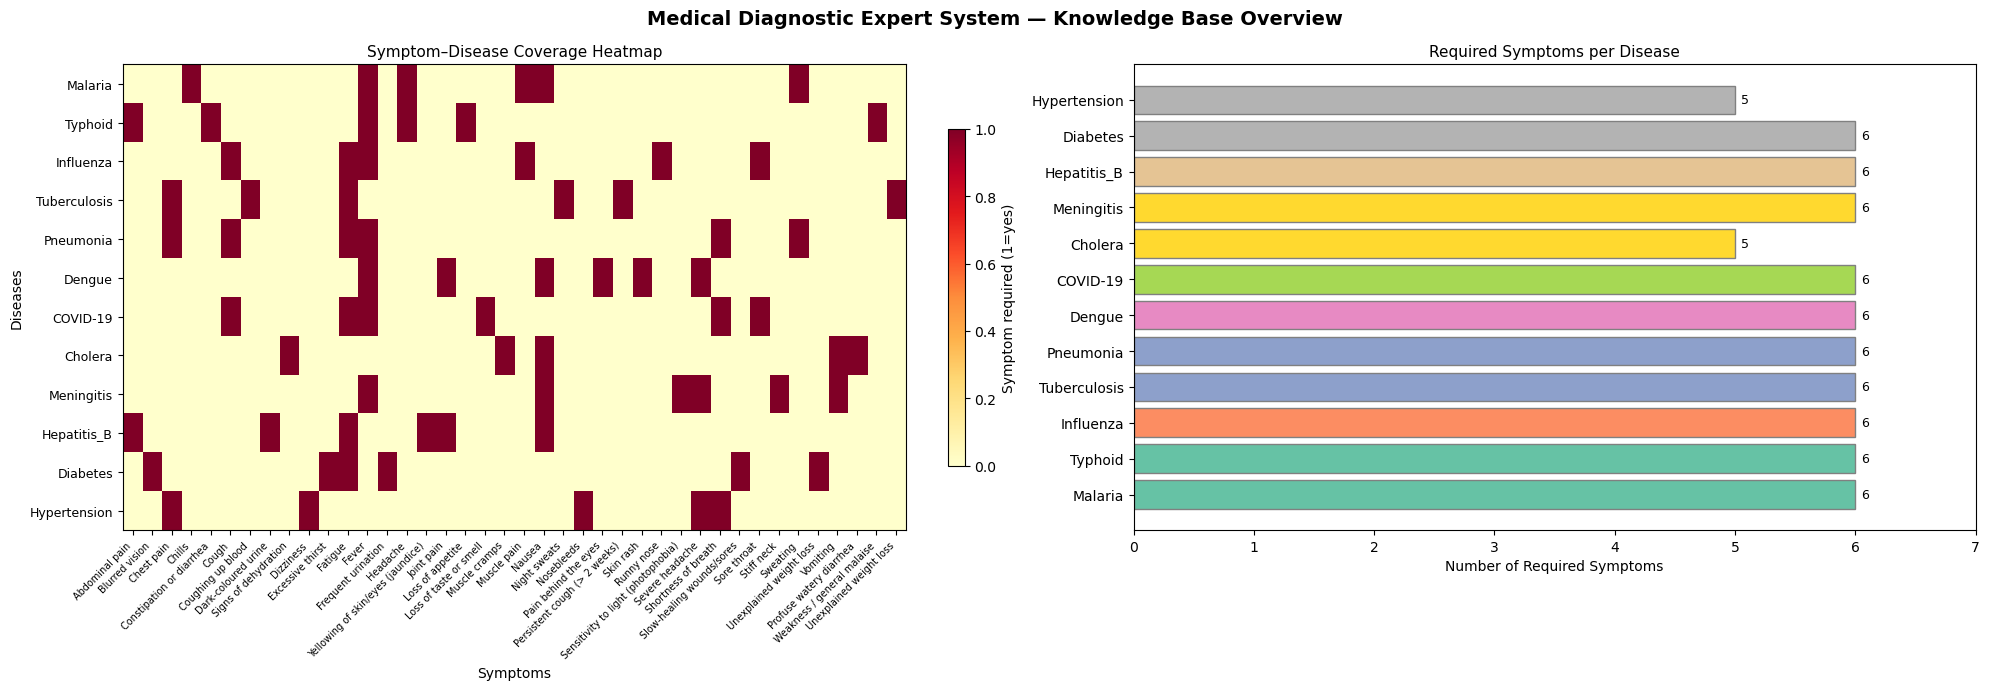

Chart saved as knowledge_base_overview.png


In [15]:
# =============================================================
# VISUALISATIONS
# 1. Symptom–Disease heatmap (which diseases share symptoms)
# 2. Symptom count per disease bar chart
# =============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

diseases = list(DISEASE_RULES.keys())
all_syms = sorted({s for syms in DISEASE_RULES.values() for s in syms})

# Build binary matrix: rows = diseases, cols = symptoms
matrix = np.array(
    [[1 if s in DISEASE_RULES[d] else 0 for s in all_syms] for d in diseases],
    dtype=float
)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Medical Diagnostic Expert System — Knowledge Base Overview',
             fontsize=14, fontweight='bold')

# ── Heatmap ───────────────────────────────────────────────────
ax1 = axes[0]
im  = ax1.imshow(matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax1.set_xticks(range(len(all_syms)))
ax1.set_xticklabels([SYMPTOM_LABELS.get(s, s) for s in all_syms],
                    rotation=45, ha='right', fontsize=7)
ax1.set_yticks(range(len(diseases)))
ax1.set_yticklabels(diseases, fontsize=9)
ax1.set_title('Symptom–Disease Coverage Heatmap', fontsize=11)
ax1.set_xlabel('Symptoms')
ax1.set_ylabel('Diseases')
plt.colorbar(im, ax=ax1, fraction=0.02, label='Symptom required (1=yes)')

# ── Bar chart: symptom count per disease ─────────────────────
ax2     = axes[1]
counts  = [len(DISEASE_RULES[d]) for d in diseases]
colours = plt.cm.Set2(np.linspace(0, 1, len(diseases)))
bars    = ax2.barh(diseases, counts, color=colours, edgecolor='grey')
ax2.set_xlabel('Number of Required Symptoms')
ax2.set_title('Required Symptoms per Disease', fontsize=11)
ax2.set_xlim(0, max(counts) + 1)
for bar, cnt in zip(bars, counts):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             str(cnt), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('knowledge_base_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as knowledge_base_overview.png')

---
### End of Notebook
**MSIT5205 – Advanced Artificial Intelligence** | Medical Diagnostic Expert System  
*Disclaimer: Educational purposes only. Not a substitute for professional medical advice.*